In [1]:
import sys
print(sys.executable)


C:\Users\Parth\AppData\Local\Programs\Python\Python311\python.exe


In [2]:
import sys
!{sys.executable} -m pip install scikit-learn



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: C:\Users\Parth\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
ds=pd.read_csv('Linear Regression - Sheet1.csv')

In [5]:
ds.isnull().sum()

X    0
Y    0
dtype: int64

In [6]:
ds.head(3)

,X,Y
0,1,3.888889
1,2,4.555556
2,3,5.222222


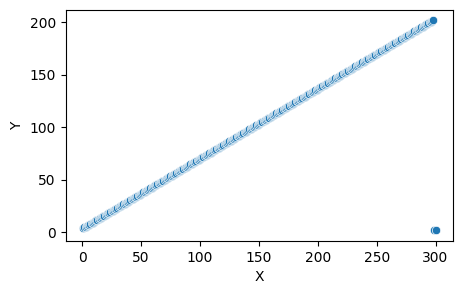

In [7]:
plt.figure(figsize=(5,3))
sns.scatterplot(x="X",y="Y",data=ds)
plt.show()

In [8]:
x=ds[["X"]]
y=ds["Y"]

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [12]:
lr.score(x_test,y_test)*100

99.6613741998755

In [13]:
lr.predict([[1]])

C:\Users\Parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([7.21858323])

In [14]:
#y=m*x+c

In [15]:
lr.coef_

array([0.6331428])

In [16]:
lr.intercept_

6.585440426796296

In [17]:
y_prd=lr.predict(x)

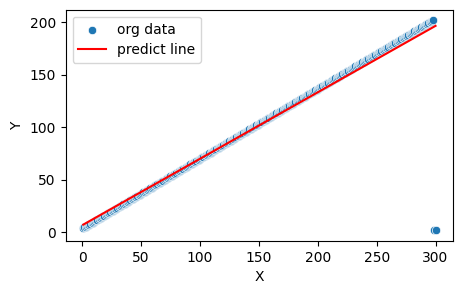

In [18]:
plt.figure(figsize=(5,3))
sns.scatterplot(x="X",y="Y",data=ds)
plt.plot(ds["X"],y_prd,c="red")
plt.legend(["org data","predict line"])
plt.savefig("predict.jpg")
plt.show()

In [19]:
# MULTIPLE LINEAR REGRESSION

In [20]:
ds=pd.read_csv("Downloads/Student_Performance.csv")

In [21]:
ds.drop('Extracurricular Activities',axis=1,inplace=True)
ds.head(3)


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0


In [22]:
ds.shape

(10000, 5)

In [23]:
ds.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

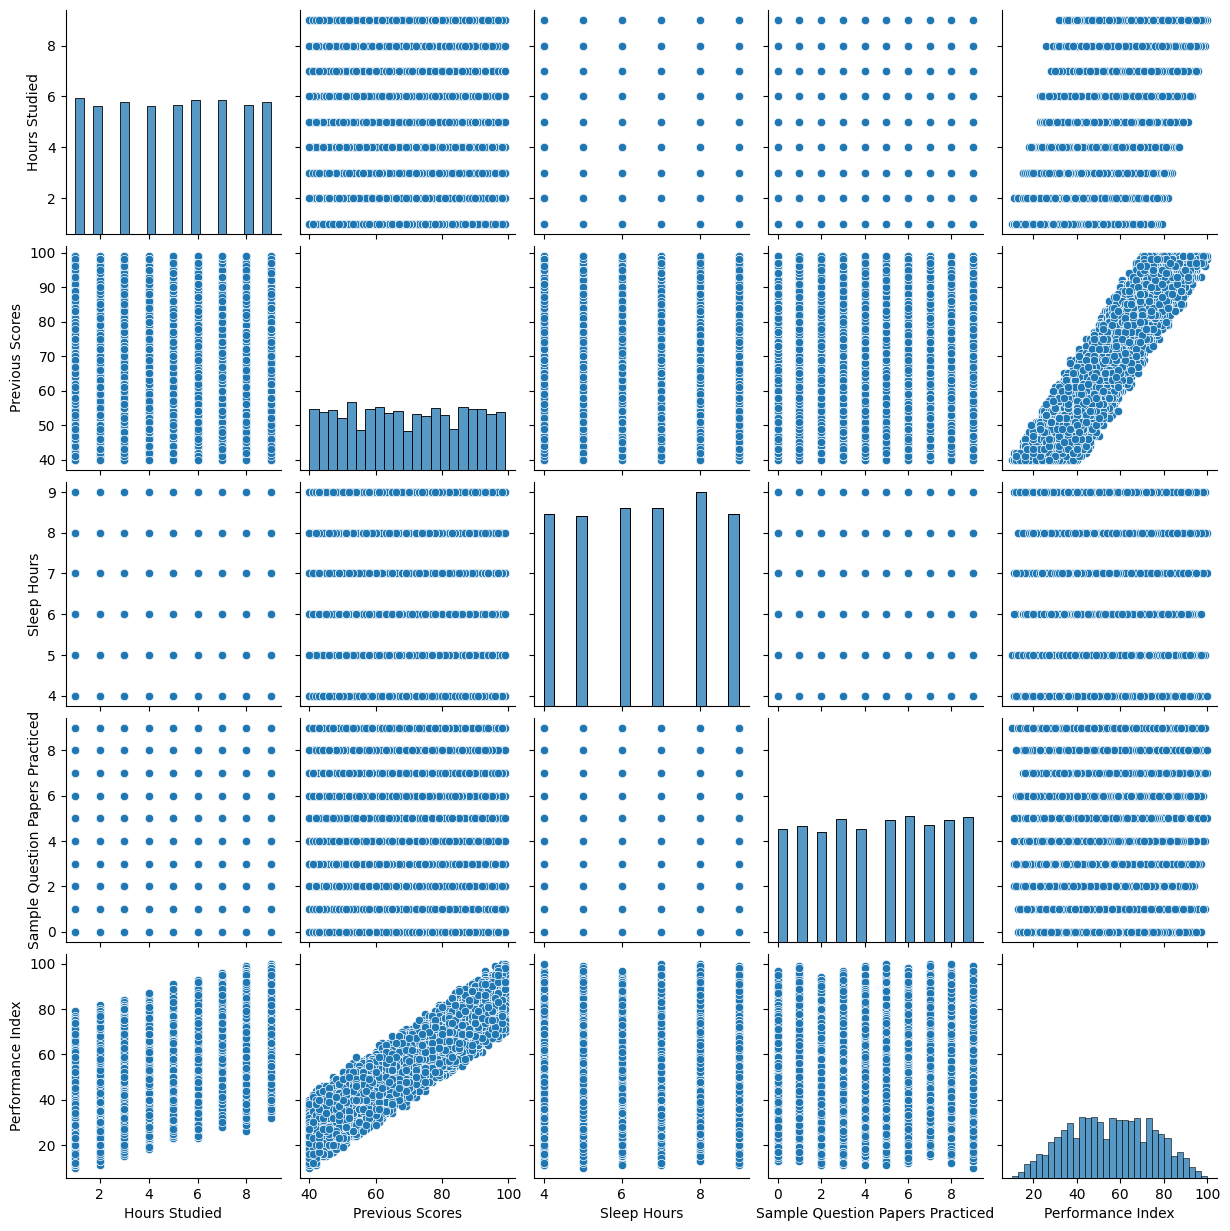

In [24]:
sns.pairplot(data=ds)
plt.show()

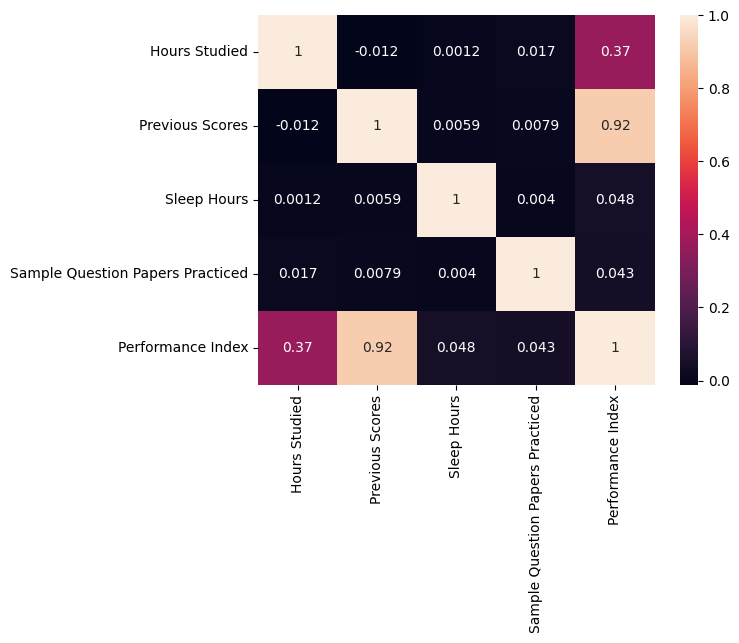

In [25]:
sns.heatmap(data=ds.corr(),annot=True)
plt.show()

In [26]:
x=ds.iloc[:,:-1]
y=ds["Performance Index"]

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [29]:
x.ndim

2

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [32]:
lr.score(x_test,y_test)*100

98.87144552384186

In [33]:
lr.coef_

array([2.85289351, 1.01703572, 0.47331832, 0.19172629])

In [34]:
lr.intercept_

-33.60206732749263

In [35]:
# y=m1x1+m2x2+m3x3+m4x4+c
lr.predict(x_test)

array([55.00786377, 22.31444624, 47.59404705, ..., 16.48182916,
       63.64243731, 46.23799491])

In [36]:
# POLYNOMIAL REGRESSION

In [37]:
ds=pd.read_csv("Downloads/Ice_cream selling data.csv")

In [38]:
ds.head(3)

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001


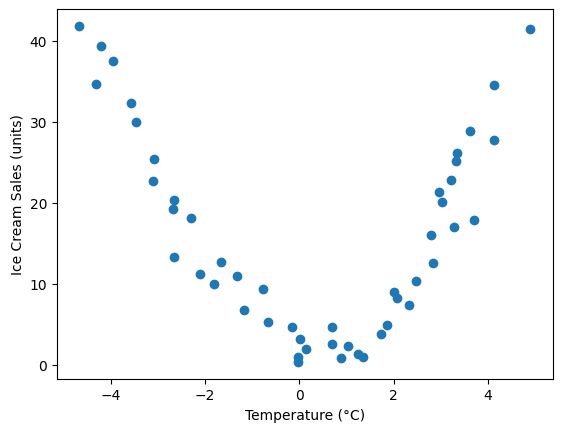

In [39]:
plt.scatter(ds["Temperature (°C)"],ds["Ice Cream Sales (units)"])
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales (units)")
plt.show()

In [40]:
ds.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [41]:
# x should always be multi-dimensional
x=ds[["Temperature (°C)"]]
y=ds["Ice Cream Sales (units)"]

In [42]:
x.ndim

2

In [43]:
y.ndim

1

In [44]:
from sklearn.preprocessing import PolynomialFeatures

In [45]:
pf=PolynomialFeatures(degree=2)
pf.fit(x)
x=pf.transform(x)

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [48]:
from sklearn.linear_model import LinearRegression

In [49]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [50]:
lr.score(x_test,y_test)*100

84.3055137193884

In [51]:
prd=lr.predict(x)

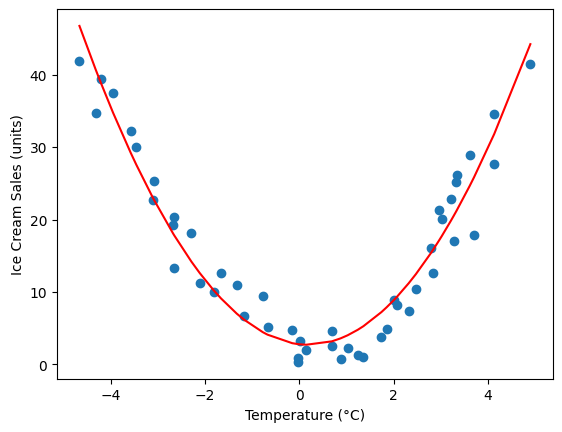

In [52]:
plt.scatter(ds["Temperature (°C)"],ds["Ice Cream Sales (units)"])
plt.plot(ds["Temperature (°C)"],prd,c="red")
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales (units)")
plt.show()

In [53]:
 #y=m1x1+m2x2^2+c
lr.coef_

array([ 0.        , -0.70641926,  1.87145125])

In [54]:
lr.intercept_

2.7683058295738583

##TRYING LASSO REGRESSION

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [56]:
ds=pd.read_csv(r"C:\Users\Parth\Downloads\winequality-red.csv",sep=";")

In [57]:
ds.head(7)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5


In [58]:
ds.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

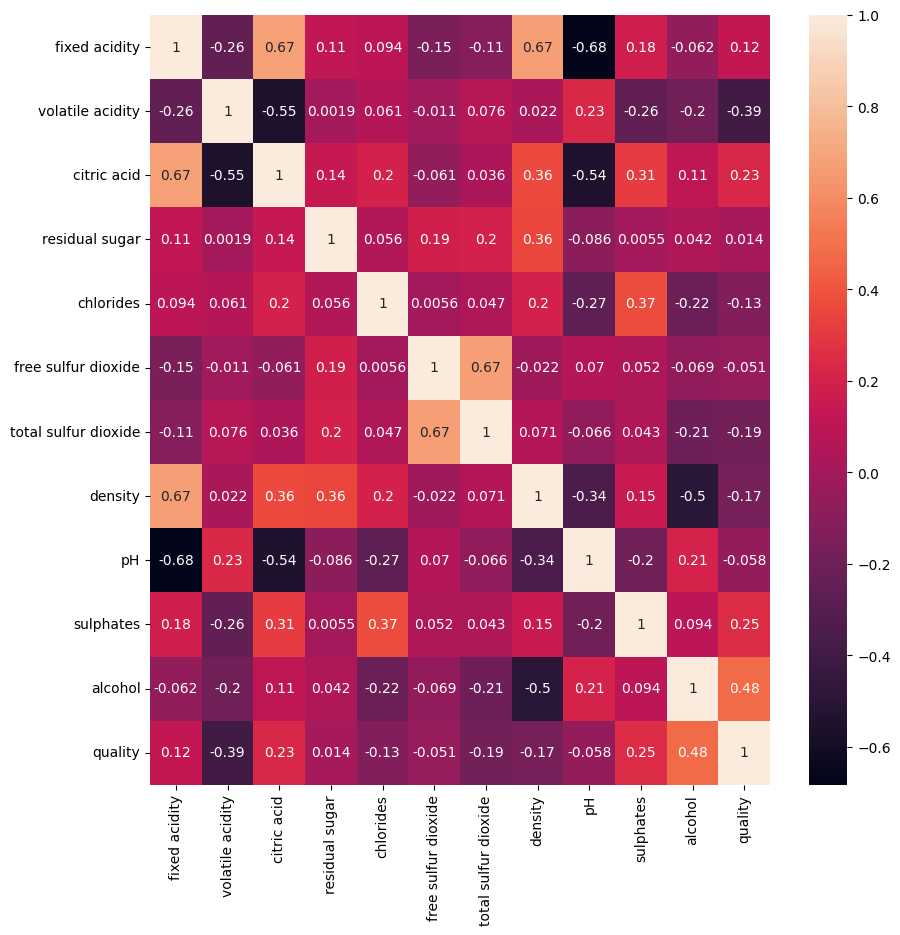

In [59]:
plt.figure(figsize=(10,10))
sns.heatmap(data=ds.corr(),annot=True)
plt.show()

In [60]:
x=ds.iloc[:,:-1]
x.ndim
x

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [61]:
y=ds["quality"]

In [62]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [63]:
#from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [64]:
lr.score(x_test,y_test)*100

40.318034127962335

In [65]:
lr.coef_

array([ 2.30853339e-02, -1.00130443e+00, -1.40821461e-01,  6.56431104e-03,
       -1.80650315e+00,  5.62733439e-03, -3.64444893e-03, -1.03515936e+01,
       -3.93687732e-01,  8.41171623e-01,  2.81889567e-01])

In [66]:
prd=lr.predict(x)

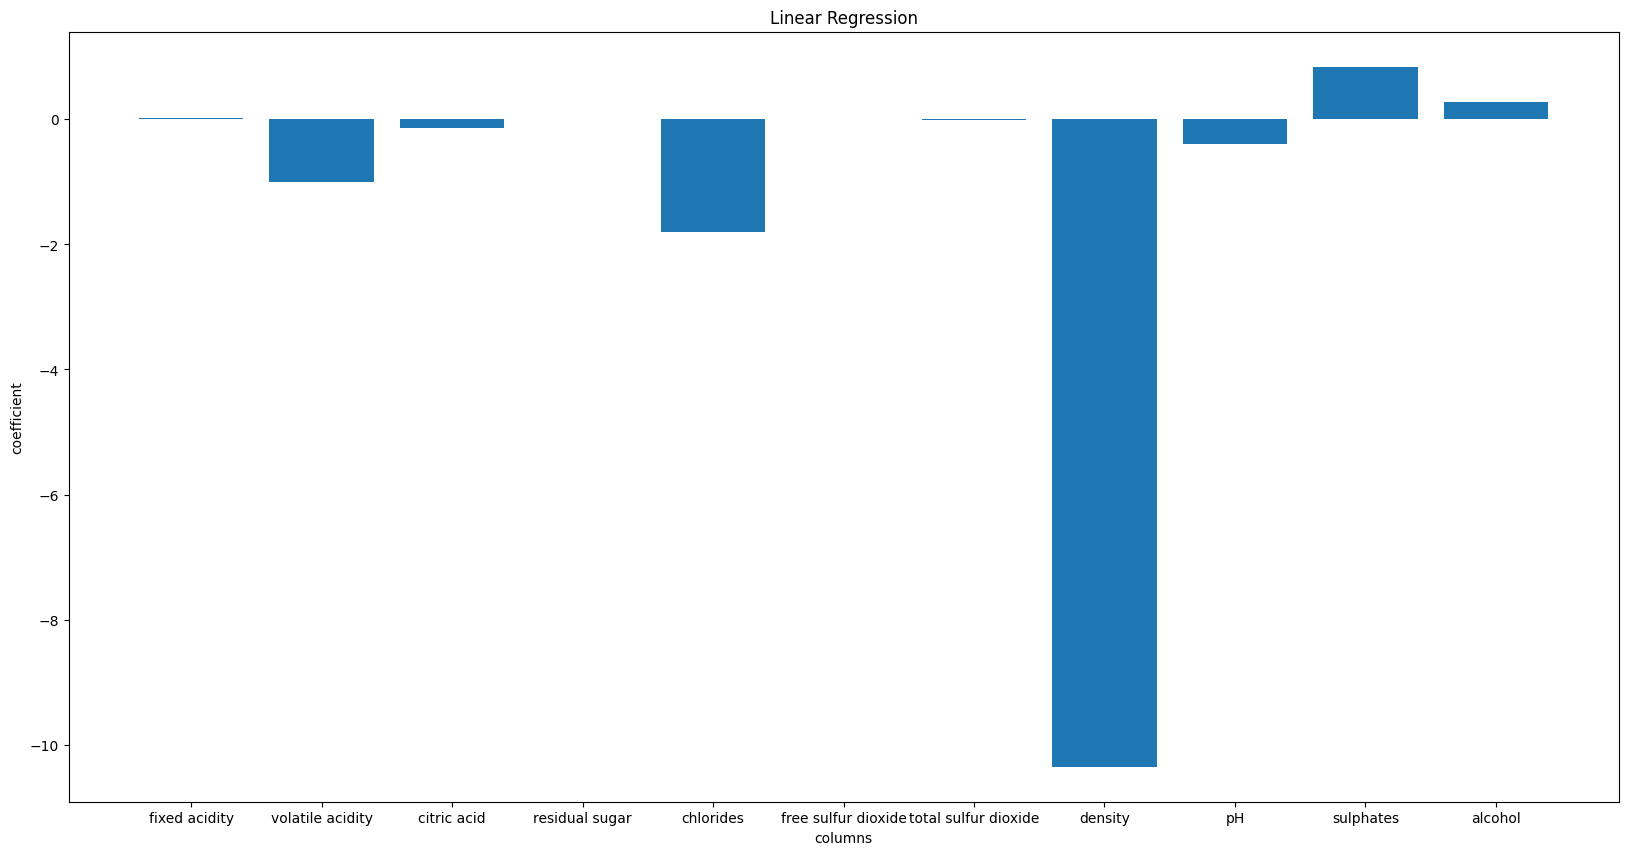

In [67]:
plt.figure(figsize=(20,10))
plt.bar(x.columns,lr.coef_)
plt.title("Linear Regression")
plt.xlabel("columns")
plt.ylabel("coefficient")
plt.show()

In [68]:
prd

array([5.04834495, 5.14680331, 5.21037447, ..., 5.94454528, 5.48826793,
       5.98429691])

In [69]:
sc=StandardScaler()
sc.fit(x)
x=pd.DataFrame(sc.transform(x),columns=x.columns)
x

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246
1,-0.298547,1.967442,-1.391472,0.043416,0.223875,0.872638,0.624363,0.028261,-0.719933,0.128950,-0.584777
2,-0.298547,1.297065,-1.186070,-0.169427,0.096353,-0.083669,0.229047,0.134264,-0.331177,-0.048089,-0.584777
3,1.654856,-1.384443,1.484154,-0.453218,-0.264960,0.107592,0.411500,0.664277,-0.979104,-0.461180,-0.584777
4,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246
...,...,...,...,...,...,...,...,...,...,...,...
1594,-1.217796,0.403229,-0.980669,-0.382271,0.053845,1.542054,-0.075043,-0.978765,0.899886,-0.461180,0.072294
1595,-1.390155,0.123905,-0.877968,-0.240375,-0.541259,2.211469,0.137820,-0.862162,1.353436,0.601055,0.729364
1596,-1.160343,-0.099554,-0.723916,-0.169427,-0.243707,1.255161,-0.196679,-0.533554,0.705508,0.542042,0.541630
1597,-1.390155,0.654620,-0.775267,-0.382271,-0.264960,1.542054,-0.075043,-0.676657,1.677400,0.305990,-0.209308


In [70]:
from sklearn.linear_model import Lasso,Ridge

In [71]:
la=Lasso(alpha=1)
la.fit(x_train,y_train)
la.score(x_test,y_test)*100

0.9014670905063582

In [72]:
la.coef_

array([ 0.        , -0.        ,  0.        ,  0.        , -0.        ,
        0.        , -0.00397837, -0.        , -0.        ,  0.        ,
        0.        ])

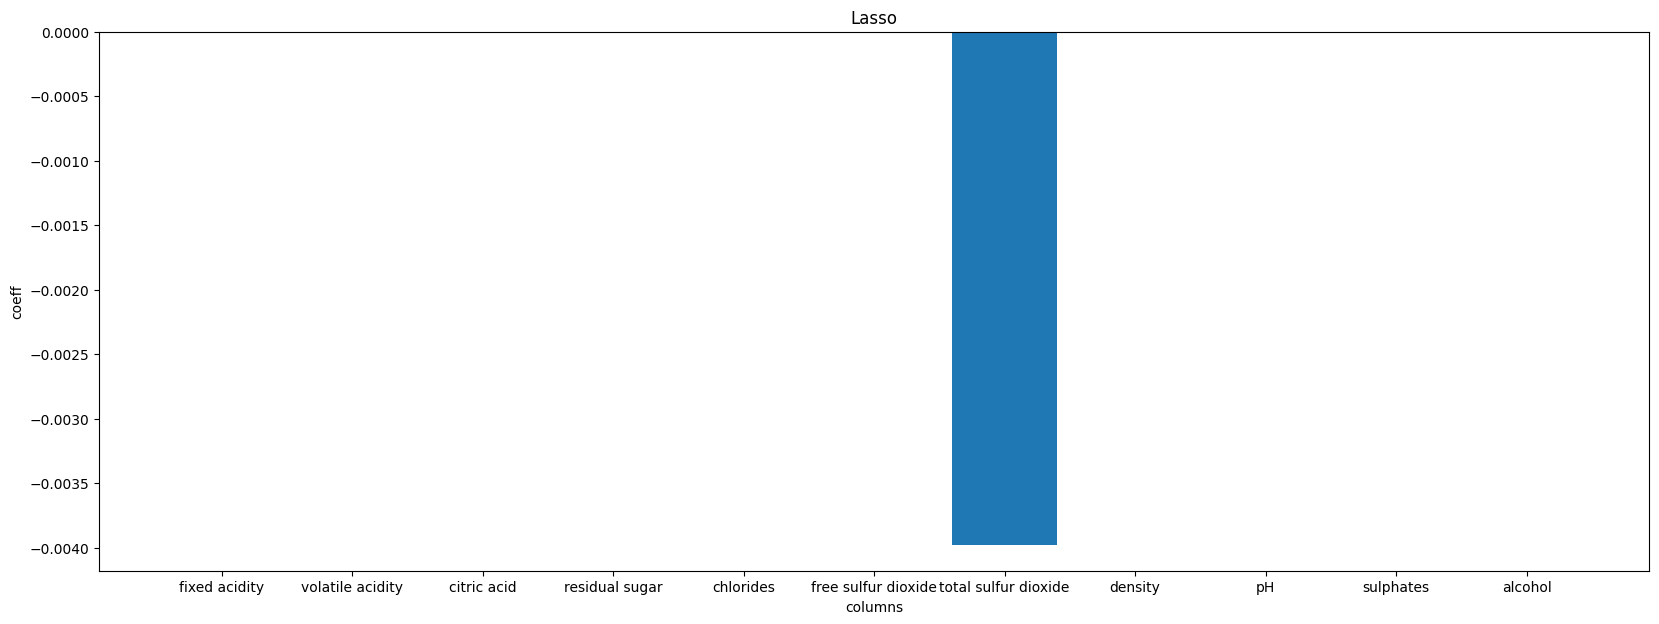

In [73]:
plt.figure(figsize=(20,7))
plt.bar(x.columns,la.coef_)
plt.title("Lasso")
plt.xlabel("columns")
plt.ylabel("coeff")
plt.show()

In [74]:
ri=Ridge(alpha=2)
ri.fit(x_train,y_train)
ri.score(x_test,y_test)*100

39.5512644553755

Text(0, 0.5, 'coefficients')

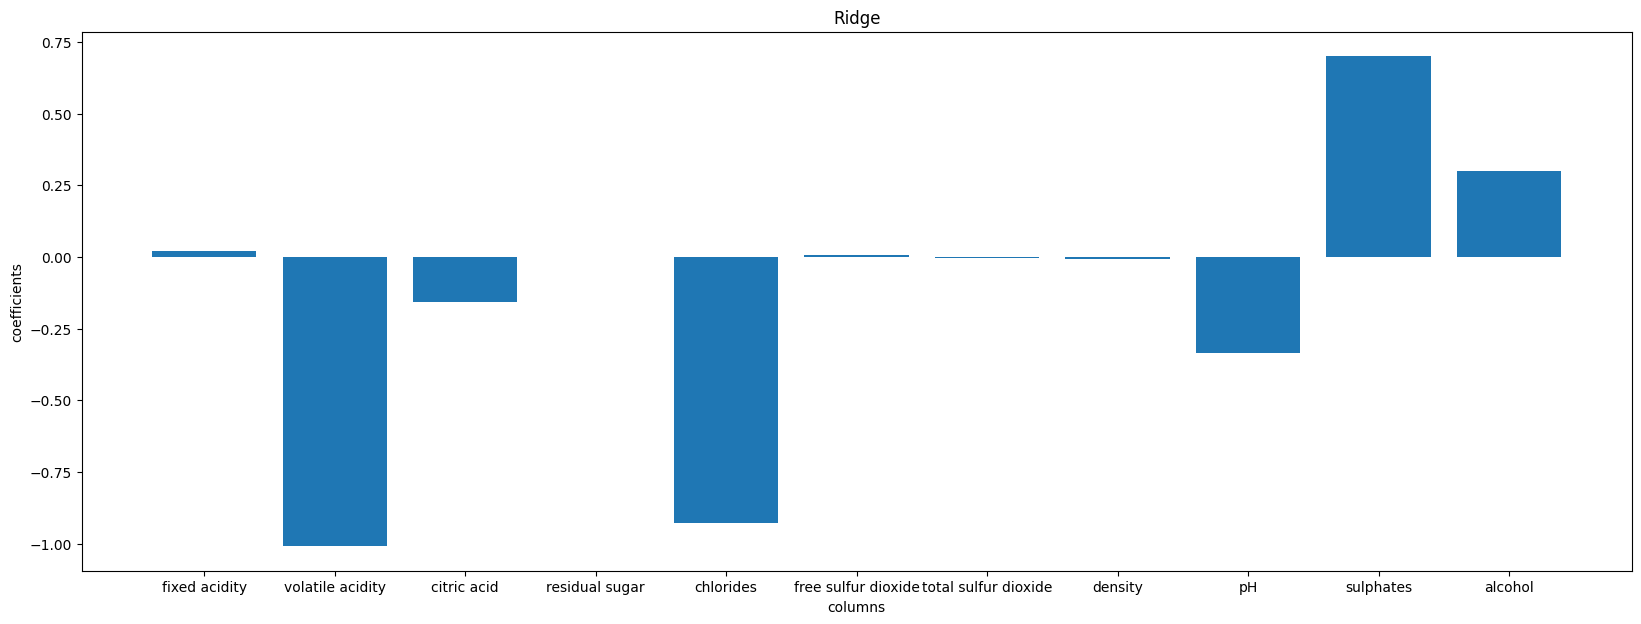

In [75]:
plt.figure(figsize=(20,7))
plt.bar(x.columns,ri.coef_)
plt.title("Ridge")
plt.xlabel("columns")
plt.ylabel("coefficients")


In [76]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

In [77]:
df=pd.DataFrame({"col_name":x.columns,"LinearRegression":lr.coef_,"Lasso":la.coef_,"Ridge":ri.coef_})
df

,col_name,LinearRegression,Lasso,Ridge
0,fixed acidity,0.023085,0.000000,0.022229
1,volatile acidity,-1.001304,-0.000000,-1.008476
2,citric acid,-0.140821,0.000000,-0.156906
3,residual sugar,0.006564,0.000000,-0.000456
4,chlorides,-1.806503,-0.000000,-0.928781
5,free sulfur dioxide,0.005627,0.000000,0.005737
6,total sulfur dioxide,-0.003644,-0.003978,-0.003528
7,density,-10.351594,-0.000000,-0.006814
8,pH,-0.393688,-0.000000,-0.335750
9,sulphates,0.841172,0.000000,0.699835


In [78]:
ds.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


In [79]:
ds.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [80]:
from sklearn.linear_model import LogisticRegression

In [81]:
from sklearn.model_selection import train_test_split

In [82]:
x=ds.iloc[:,:-1]
y=ds["quality"]

In [83]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
lr=LogisticRegression()

In [84]:
lr.fit(x_train,y_train)
lr.score(x_test,y_test)*100

C:\Users\Parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


55.00000000000001

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='fixed acidity', ylabel='quality'>

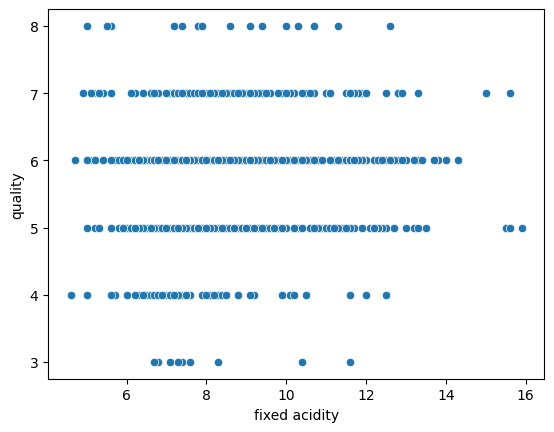

In [86]:
sns.scatterplot(x="fixed acidity",y="quality",data=ds)


In [87]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable


In [88]:
ds=pd.read_csv(r"C:\Users\Parth\Downloads\breast_cancer.csv")

In [89]:
ds

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
678,3,1,1,1,3,2,1,1,1,2
679,2,1,1,1,2,1,1,1,1,2
680,5,10,10,3,7,3,8,10,2,4
681,4,8,6,4,3,4,10,6,1,4


In [90]:
ds.drop(['Uniformity of Cell Size','Uniformity of Cell Shape','Marginal Adhesion','Single Epithelial Cell Size','Bare Nuclei','Bland Chromatin','Normal Nucleoli'],axis=1,inplace=True)

In [91]:
ds.head(3)

,Clump Thickness,Mitoses,Class
0,5,1,2
1,5,1,2
2,3,1,2


In [92]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Clump Thickness', ylabel='Mitoses'>

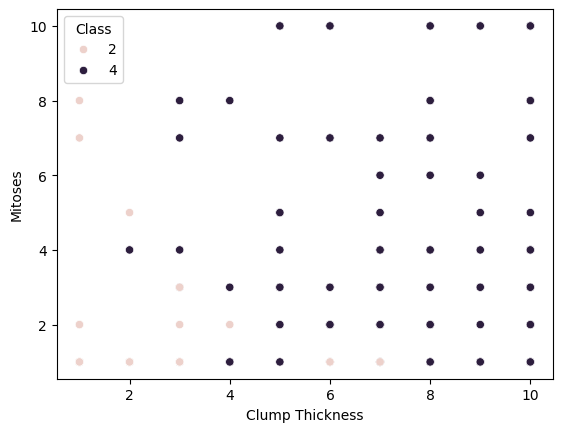

In [94]:
sns.scatterplot(x="Clump Thickness",y="Mitoses",data=ds,hue="Class")

In [95]:
x=ds.iloc[:,:-1]
y=ds["Class"]
x

,Clump Thickness,Mitoses
0,5,1
1,5,1
2,3,1
3,6,1
4,4,1
...,...,...
678,3,1
679,2,1
680,5,2
681,4,1


In [96]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [97]:
print(lr.score(x_test,y_test)*100)

87.59124087591242


In [98]:
from sklearn.preprocessing import PolynomialFeatures

In [108]:
pf=PolynomialFeatures(degree=3)

In [109]:
pf.fit(x)

PolynomialFeatures(degree=3)

In [110]:
ds

,Clump Thickness,Mitoses,Class
0,5,1,2
1,5,1,2
2,3,1,2
3,6,1,2
4,4,1,2
...,...,...,...
678,3,1,2
679,2,1,2
680,5,2,4
681,4,1,4


In [111]:
x

,0,1,2
0,1.0,5.0,1.0
1,1.0,5.0,1.0
2,1.0,3.0,1.0
3,1.0,6.0,1.0
4,1.0,4.0,1.0
...,...,...,...
678,1.0,3.0,1.0
679,1.0,2.0,1.0
680,1.0,5.0,2.0
681,1.0,4.0,1.0


In [112]:
x=pd.DataFrame(pf.transform(x))
x

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.0,1.0,5.0,1.0,1.0,5.0,1.0,25.0,5.0,1.0,1.0,5.0,1.0,25.0,5.0,1.0,125.0,25.0,5.0,1.0
1,1.0,1.0,5.0,1.0,1.0,5.0,1.0,25.0,5.0,1.0,1.0,5.0,1.0,25.0,5.0,1.0,125.0,25.0,5.0,1.0
2,1.0,1.0,3.0,1.0,1.0,3.0,1.0,9.0,3.0,1.0,1.0,3.0,1.0,9.0,3.0,1.0,27.0,9.0,3.0,1.0
3,1.0,1.0,6.0,1.0,1.0,6.0,1.0,36.0,6.0,1.0,1.0,6.0,1.0,36.0,6.0,1.0,216.0,36.0,6.0,1.0
4,1.0,1.0,4.0,1.0,1.0,4.0,1.0,16.0,4.0,1.0,1.0,4.0,1.0,16.0,4.0,1.0,64.0,16.0,4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,1.0,1.0,3.0,1.0,1.0,3.0,1.0,9.0,3.0,1.0,1.0,3.0,1.0,9.0,3.0,1.0,27.0,9.0,3.0,1.0
679,1.0,1.0,2.0,1.0,1.0,2.0,1.0,4.0,2.0,1.0,1.0,2.0,1.0,4.0,2.0,1.0,8.0,4.0,2.0,1.0
680,1.0,1.0,5.0,2.0,1.0,5.0,2.0,25.0,10.0,4.0,1.0,5.0,2.0,25.0,10.0,4.0,125.0,50.0,20.0,8.0
681,1.0,1.0,4.0,1.0,1.0,4.0,1.0,16.0,4.0,1.0,1.0,4.0,1.0,16.0,4.0,1.0,64.0,16.0,4.0,1.0


In [113]:
x.shape

(683, 20)

In [114]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [115]:
from sklearn.linear_model import LogisticRegression

In [116]:
lr=LogisticRegression()
lr.fit(x_train,y_train)
lr.score(x_test,y_test)*100

C:\Users\Parth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


88.32116788321169

In [1]:
import mlxtend

ModuleNotFoundError: No module named 'mlxtend'

In [2]:
!pip install mlxtend


Defaulting to user installation because normal site-packages is not writeable


In [3]:
import mlxtend

ModuleNotFoundError: No module named 'mlxtend'

In [4]:
%pip install mlxtend

  Obtaining dependency information for mlxtend from https://files.pythonhosted.org/packages/4c/43/2fc7f76c8891aef148901f1ba3dee65c1cbac00a85ae5ee0dabc2b861256/mlxtend-0.23.4-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
    --------------------------------------- 0.0/1.4 MB 660.6 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.4 MB 751.6 kB/s eta 0:00:02
   --- ------------------------------------ 0.1/1.4 MB 798.9 kB/s eta 0:00:02
   ------- -------------------------------- 0.3/1.4 MB 1.3 MB/s eta 0:00:01
   ------- -------------------------------- 0.3/1.4 MB 1.3 MB/s eta 0:00:01
   --------------- ------------------------ 0.5/1.4 MB 1.7 MB/s eta 0:00:01
   --------------- ------------------------ 0.5/1.4 MB 1.7 MB/s eta 0:00:01
   --------------------- ------------------ 0.7/1.4 MB 


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: C:\Users\Parth\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [5]:
import mlxtend

In [6]:
!where python

C:\Python313\python.exe
C:\Users\Parth\AppData\Local\Programs\Python\Python311\python.exe
C:\Users\Parth\AppData\Local\Microsoft\WindowsApps\python.exe


In [7]:
import sys
print(sys.executable)


C:\Users\Parth\AppData\Local\Programs\Python\Python311\python.exe
